## Estadística Aplicada

Bryan Alejandro Estrada Rodriguez 1844554

Grupo 42

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
!pip install lifelines

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.7/350.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 9.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=8bf138f6f65c0a7ce869b2e0a0355e22a0bff5bc39f01caf562da42405776a58
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma


In [6]:
from lifelines import ExponentialFitter, KaplanMeierFitter

## Problema 3 Exponencial

a)

In [8]:
quiebre = pd.read_csv('quiebra.csv')
quiebre

,tiempo,mujer,quebrar
0,21,0,1
1,16,1,0
2,26,1,1
3,17,1,0
4,29,1,1
...,...,...,...
95,12,0,1
96,22,0,1
97,30,0,0
98,10,0,0


In [10]:
## Funcion de supervivencia
exponen = ExponentialFitter().fit(quiebre['tiempo'],quiebre['quebrar'])

In [11]:
exponen.print_summary()

<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 100 total observations, 52 right-censored observations>
   number of observations = 100
number of events observed = 48
           log-likelihood = -212.48
               hypothesis = lambda_ != 0

---
          coef   se(coef)   coef lower 95%   coef upper 95%
lambda_  30.77       4.44            22.07            39.48

          cmp to    z      p   -log2(p)
lambda_     0.00 6.93 <0.005      37.77
---
AIC = 426.95

b)

(0.0, 0.1)

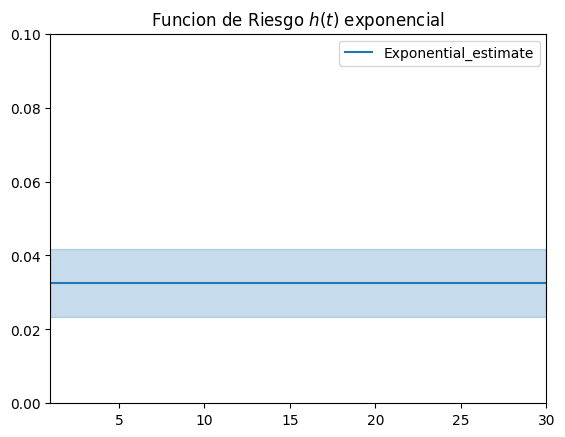

In [12]:
exponen.plot_hazard()
plt.title('Funcion de Riesgo $h(t)$ exponencial')
plt.xlim(1,30)
plt.ylim(0,0.1)

c)

In [13]:
# a) tasa de riesgo
exponen.hazard_

,Exponential_estimate
1.000000,0.032498
1.292929,0.032498
1.585859,0.032498
1.878788,0.032498
2.171717,0.032498
...,...
28.828283,0.032498
29.121212,0.032498
29.414141,0.032498
29.707071,0.032498


El riesgo que corre según la exponencial una empresa de quebrar es constante en 3.24%


## Problema 4 Weibull

a)


In [14]:
from lifelines import WeibullFitter

In [15]:
## Funcion de supervivencia
mweibull = WeibullFitter().fit(quiebre['tiempo'],quiebre['quebrar'])

b)

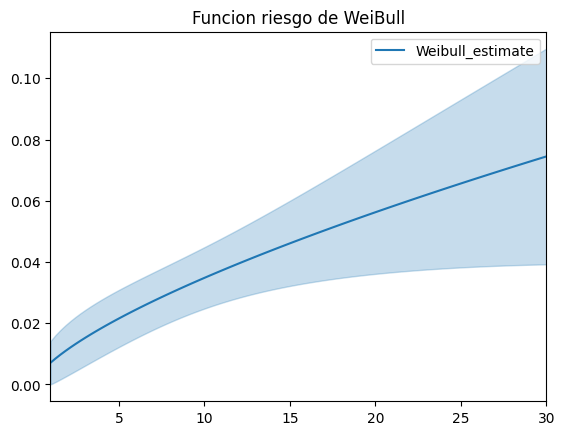

In [16]:
mweibull.plot_hazard()
plt.title('Funcion riesgo de WeiBull')
plt.xlim(1,30);

c)

El riesgo con el modelo WeiBull tiende a ser creciente con el tiempo y forma una pendiente positiva

## Problema 5 Log-Normal

a)


In [17]:
from lifelines import LogNormalFitter

In [18]:
## Funcion de supervivencia
qlogn = LogNormalFitter().fit(quiebre['tiempo'],quiebre['quebrar'])

b)

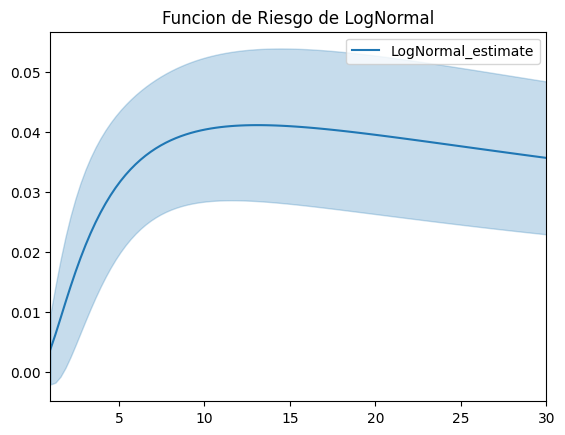

In [19]:
# Riesgo de Log Normal
qlogn.plot_hazard()
plt.title('Funcion de Riesgo de LogNormal')
plt.xlim(1,30);


In [26]:
datos= qlogn.hazard_
datos.head(60)

,LogNormal_estimate
1.000000,0.003749
1.292929,0.006219
1.585859,0.008870
1.878788,0.011543
2.171717,0.014143
2.464646,0.016613
2.757576,0.018927
3.050505,0.021072
3.343434,0.023047
3.636364,0.024858


c)

El periodo de resgo de quebrar donde es creciente es del 0 al los 13.01 años aproximadamente. Por otra parte, el periodo donde el riesgo de decreciente es de los 13.01 años en adelante.


## Problema 6 Kaplan-Meier

a)

In [ ]:
from lifelines import KaplanMeierFitter

In [ ]:
## Funcion de supervivencia
KMquiebre = KaplanMeierFitter().fit(quiebre['tiempo'], quiebre['quebrar'])

In [ ]:
## Mediana de la función de supervivencia
KMquiebre.median_survival_time_

23.0

La mediana del tiempo de supervivencia es 12 años, lo que significa que la mitad de las empresas han terminado en quiebra el año 12 o que la mitad de las empresas duran mas de 12 años

b)

In [ ]:
## Separar la base de datos mujeres (1) y hombres (0)

mujer = quiebre.query('mujer == 1')

hombre = quiebre.query ('mujer == 0')

In [ ]:
## Crear la funcion de Kaplan-Meier de las mujeres

KMquiebrem = KaplanMeierFitter().fit(mujer ['tiempo'], mujer['quebrar'])
KMquiebreh = KaplanMeierFitter().fit(hombre['tiempo'], hombre['quebrar'])

Text(0, 0.5, 'Quiebre')

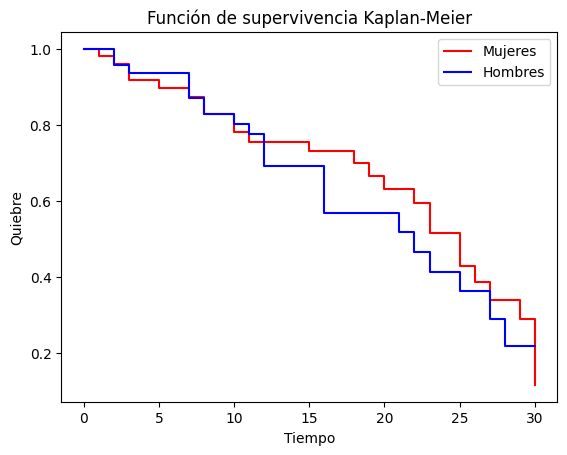

In [ ]:
KMquiebrem.plot_survival_function(ci_show=False,color='red',label='Mujeres')
KMquiebreh.plot_survival_function(ci_show=False,color='blue',label='Hombres')
plt.title('Función de supervivencia Kaplan-Meier')
plt.xlabel('Tiempo')
plt.ylabel('Quiebre')


Como se muestra en la grafica podemos ver que las empresas que estan lideradas por hombres si tienden a quebrar mas rapido que las empresas lideradas por hmujeres.

c)

Prueba de hipotesis Log-rank-test

$H0: S(1)=S(2)$ Funciones de supervivencia iguales

$H0: S(1) ≠ S(2)$ Funciones de supervivencia distintas





In [ ]:
from lifelines.statistics import logrank_test

In [ ]:
LRT = logrank_test(mujer['tiempo'], hombre['tiempo'],mujer['quebrar'], hombre['quebrar'])

In [ ]:
LRT.print_summary()


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.28 0.59      0.75

In [ ]:
LRT.p_value.round(2)

0.59

In [ ]:
KMquiebrem.median_survival_time_

25.0

Como el Pvalor=0.59 es mayor que nuestra alfa=0.05 no rechazamos H0 y despues de analizar las hipotesis podemos decir que el argumento del profe es erroneo ya que los datos son iguales por lo que el sexo no tienen efecto en el riesgo de quiebre de las empresas.